In [ ]:
import glob

files = glob.glob("*.xls") + glob.glob("*.csv")

print("Total files:", len(files))

for f in files:
    print(f)

Total files: 15
dataset_Imperialism_and_Colonialism.xls
dataset_Human_Crime_and_Justice.xls
dataset_Scientific_Discovery_and_Technology.xls
dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls
dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls
dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls
dataset_Human_Human_Nature_and_Morality.xls
dataset_Human_Scientific_Discovery_and_Technology.xls
dataset_Human_Class_Society_and_Social_Evolution.xls
dataset_Class_Society_and_Social_Evolution.xls
dataset_Human_Imperialism_and_Colonialism.xls
dataset_Crime_and_Justice.xls
dataset_Human_Nature_and_Morality.xls
dataset_Class3_Crime_and_Justice_Charles_Dickens.xls
dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.xls


In [ ]:
import pandas as pd

for file in files:
    df = pd.read_csv(file)
    print(f"{file:<70} {len(df)} rows")

dataset_Imperialism_and_Colonialism.xls                                50 rows
dataset_Human_Crime_and_Justice.xls                                    50 rows
dataset_Scientific_Discovery_and_Technology.xls                        50 rows
dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls 50 rows
dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls  50 rows
dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls           50 rows
dataset_Human_Human_Nature_and_Morality.xls                            50 rows
dataset_Human_Scientific_Discovery_and_Technology.xls                  50 rows
dataset_Human_Class_Society_and_Social_Evolution.xls                   50 rows
dataset_Class_Society_and_Social_Evolution.xls                         50 rows
dataset_Human_Imperialism_and_Colonialism.xls                          50 rows
dataset_Crime_and_Justice.xls                                          50 rows
dataset_Human_Nature_and_Morality.xls               

In [ ]:
import pandas as pd

frames = []

for file in files:
    df = pd.read_csv(file)
    frames.append(df)

dataset = pd.concat(frames, ignore_index=True)

print(dataset.shape)

(750, 3)


In [ ]:
print(dataset["Class"].value_counts())

Class
AI_Normal                      250
Human                          250
AI_Stylized_Charles_Dickens    250
Name: count, dtype: int64


In [ ]:
dataset.to_csv("final_dataset.csv", index=False)

print("Dataset Saved!")

Dataset Saved!


In [ ]:
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

dataset.head()

,Topic,Paragraph,Class
0,Imperialism and Colonialism,“Quite so. I have a kind of intuition that way...,Human
1,Scientific Discovery and Technology,"We did not, however. Not a word came to us eit...",Human
2,Scientific Discovery and Technology,The intersection of scientific discovery and t...,AI_Normal
3,Human Nature and Morality,"It is a melancholy truth, oft repeated by the ...",AI_Stylized_Charles_Dickens
4,Human Nature and Morality,"Consider the soul of a man, that curious clock...",AI_Stylized_Charles_Dickens


In [ ]:
import nltk
import numpy as np
import pandas as pd
import spacy
import string

from collections import Counter
from sklearn.model_selection import train_test_split

In [ ]:
nlp = spacy.load("en_core_web_sm")

print("SpaCy Loaded Successfully")

SpaCy Loaded Successfully


In [32]:
import textstat
from collections import Counter
import string

def dependency_depth(token):
    if len(list(token.children)) == 0:
        return 1
    return 1 + max(dependency_depth(child) for child in token.children)


def extract_features(text):

    doc = nlp(text)

    words = [
        token.text.lower()
        for token in doc
        if token.is_alpha
    ]

    total_words = len(words)
    unique_words = len(set(words))

    # -------------------
    # Type Token Ratio
    # -------------------
    ttr = unique_words / total_words if total_words else 0

    # -------------------
    # Hapax Legomena
    # -------------------
    word_counts = Counter(words)
    hapax = sum(1 for count in word_counts.values() if count == 1)

    # -------------------
    # POS Ratio
    # -------------------
    adjective_count = sum(token.pos_ == "ADJ" for token in doc)
    noun_count = sum(token.pos_ == "NOUN" for token in doc)

    adj_noun_ratio = adjective_count / noun_count if noun_count else 0

    # -------------------
    # Dependency Tree Depth
    # -------------------
    depths = [
        dependency_depth(sent.root)
        for sent in doc.sents
    ]

    avg_depth = sum(depths) / len(depths) if depths else 0

    # -------------------
    # Punctuation Counts
    # -------------------
    semicolon = text.count(";")
    comma = text.count(",")
    exclamation = text.count("!")
    question = text.count("?")
    colon = text.count(":")
    dash = text.count("-")

    punctuation_density = (
        semicolon +
        comma +
        exclamation +
        question +
        colon +
        dash
    ) / len(text) if len(text) else 0

    # -------------------
    # Readability
    # -------------------
    readability = textstat.flesch_kincaid_grade(text)

    return pd.Series({

        "TTR": ttr,

        "Hapax": hapax,

        "Adj_Noun_Ratio": adj_noun_ratio,

        "Dependency_Depth": avg_depth,

        "Semicolon": semicolon,

        "Comma": comma,

        "Exclamation": exclamation,

        "Question": question,

        "Colon": colon,

        "Dash": dash,

        "Punctuation_Density": punctuation_density,

        "Readability": readability

    })

In [34]:
features = dataset["Paragraph"].apply(extract_features)

dataset = pd.concat([dataset, features], axis=1)

In [35]:
print(dataset.columns.tolist())

['Topic', 'Paragraph', 'Class', 'TTR', 'Adj_Noun_Ratio', 'Punctuation_Density', 'TTR', 'Hapax', 'Adj_Noun_Ratio', 'Dependency_Depth', 'Semicolon', 'Comma', 'Exclamation', 'Question', 'Colon', 'Dash', 'Punctuation_Density', 'Readability']


In [36]:
from sklearn.preprocessing import LabelEncoder

X = dataset[
    [
        "TTR",
        "Hapax",
        "Adj_Noun_Ratio",
        "Dependency_Depth",
        "Semicolon",
        "Comma",
        "Exclamation",
        "Question",
        "Colon",
        "Dash",
        "Punctuation_Density",
        "Readability"
    ]
]

y = dataset["Class"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(X.head())
print(y[:5])

        TTR       TTR  Hapax  Adj_Noun_Ratio  Adj_Noun_Ratio  \
0  0.712871  0.712871   58.0        0.555556        0.555556   
1  0.662577  0.662577   84.0        0.333333        0.333333   
2  0.807692  0.807692   91.0        0.647059        0.647059   
3  0.724832  0.724832   96.0        0.538462        0.538462   
4  0.650000  0.650000   85.0        0.512195        0.512195   

   Dependency_Depth  Semicolon  Comma  Exclamation  Question  Colon  Dash  \
0              5.25        0.0    4.0          0.0       0.0    0.0   0.0   
1              7.50        0.0    7.0          0.0       0.0    0.0   1.0   
2              7.40        0.0    4.0          0.0       0.0    0.0   1.0   
3             10.00        0.0   13.0          0.0       0.0    0.0   2.0   
4              8.40        0.0    8.0          0.0       1.0    0.0   1.0   

   Punctuation_Density  Punctuation_Density  Readability  
0             0.022018             0.007339     6.627242  
1             0.017998            

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(600, 15)
(150, 15)


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
y_pred = rf.predict(X_test)

In [40]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print("Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9133333333333333

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        50
           1       0.88      0.86      0.87        50
           2       0.98      1.00      0.99        50

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150

Confusion Matrix
[[44  6  0]
 [ 6 43  1]
 [ 0  0 50]]


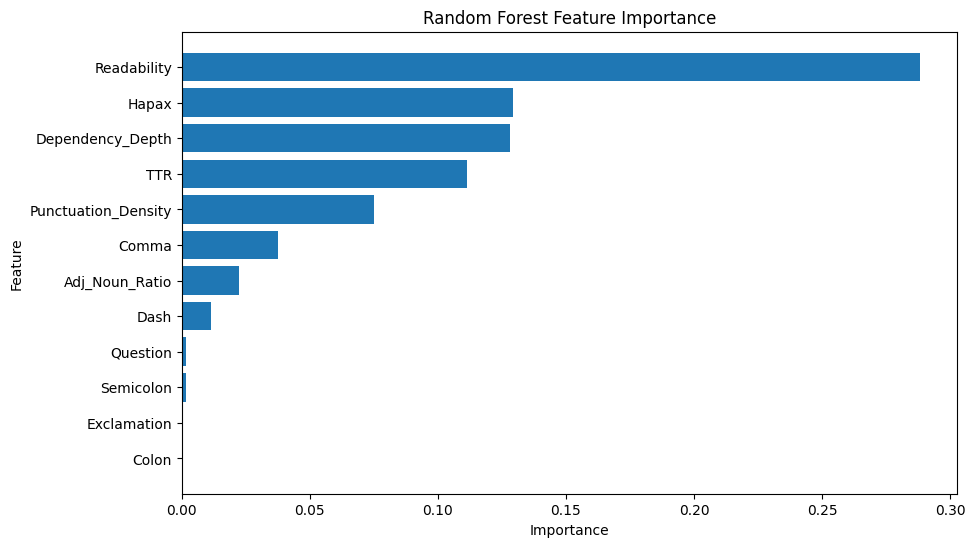

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [44]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)

print("ROC-AUC Score:", roc_auc_score(y_test, prob, multi_class="ovr"))

ROC-AUC Score: 0.9916


In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.96666667 0.95333333 0.97333333 0.99333333 0.95333333]
Average Accuracy: 0.968
